## Lei de Ampere, Lei de Faraday e Campo Magnético

Bibliotecas

In [17]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import numpy as np

Dados experimentais

In [18]:
R_exp = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20] #cm
R_exp = [r/100 for r in R_exp]  # m
V_exp = [2.6*1,2*1,1.6*1,2.5*0.5,2.05*0.5,1.9*0.5,3.7*0.2,3.2*0.2,2.8*0.2,2.5*0.2,2.1*0.2,4*0.1,3.5*0.1,3.2*0.1,2.9*0.1,2.6*0.1,2.5*0.1,2.3*0.1,2.1*0.1] #V

In [19]:
def f(x, A, B):
    return A/x + B

popt, pcov = curve_fit(f, R_exp, V_exp)
A, B = popt
print(f"A = {A:.4f}, B = {B:.4f}")
perr = np.sqrt(np.diag(pcov))
print(f"Erro padrão dos parâmetros: A = {perr[0]:.4f}, B = {perr[1]:.4f}")

x_fit = np.linspace(min(R_exp), max(R_exp), 100)
y_fit = f(x_fit, A, B)
slope, intercept, r_value, p_value, std_err = linregress(f(R_exp,*popt),V_exp)
print(f"R² = {r_value**2:.4f}")


A = 0.0570, B = -0.0118
Erro padrão dos parâmetros: A = 0.0021, B = 0.0366
R² = 0.9782


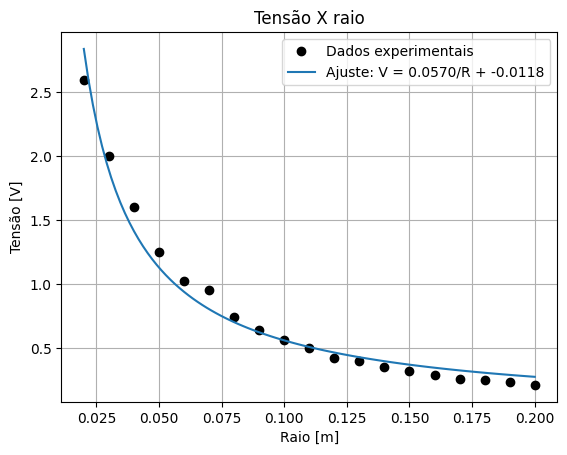

In [20]:
plt.plot(R_exp, V_exp, 'ko', label='Dados experimentais')
plt.plot(x_fit, y_fit, '-', label=f'Ajuste: V = {A:.4f}/R + {B:.4f}')
plt.xlabel('Raio [m]')
plt.ylabel('Tensão [V]')
plt.title('Tensão X raio')
plt.grid()
plt.legend()
plt.show()